# Tutorial 4.1: Smart-meter analytics and machine-learning load forecasting

This tutorial connects smart-meter exploration with day-ahead load forecasting at two scales:

- the **GEFCom2012 aggregate system load**, where regular patterns are comparatively clear; and
- one **Building Data Genome 2 education building**, where operation is more variable.

The emphasis is on transparent and interpretable features and simple machine-learning pipelines.

## Learning outcomes

By the end of the tutorial, you should be able to:

1. explore hourly meter data and identify patterns or data-quality concerns;
2. formulate day-ahead forecasting as supervised learning;
3. distinguish predictors available at the forecast origin from future information;
4. compare pooled Ridge regression, hour-specific Ridge models, a decision tree and a random forest with seasonal-naïve benchmarks;
5. reshape an hourly series into daily rows and train one model for each hour of the day;
6. evaluate day-ahead forecasts over a chronological test set; and
7. compare a transferred model with a model trained locally and explain why aggregate and individual-building loads behave differently.

## Indicative schedule

- set-up and smart-meter exploration: 20 minutes;
- forecast formulation and features: 20 minutes;
- benchmarks and machine-learning models: 25 minutes;
- hour-specific linear models and test-set evaluation: 25 minutes;
- building-level transfer and discussion: 10 minutes.

## 1. Set-up and data loading

The tutorial uses compact extracts stored in `data/tutorial_4_1`. Run the notebook from the repository root. The data-loading code is supplied.

The aggregate series is `Z21` from GEFCom2012. Its temperature column contains the competition's historical weather forecasts at 11 weather stations. In this context, `Temperature_history` denotes weather-forecast data in the historical training set; it does not mean realised temperature measurements. The building series is the electricity meter for `Rat_education_Alfonso`, a K–12 education building at the `Rat` site in Building Data Genome 2. Its temperature column contains observed weather from NOAA ISD-Lite at the nearest weather station.

Only the GEFCom extract contains target-hour weather forecasts. For simplicity, Tutorial 4.1 uses the previous day's same-hour temperature value for both datasets, giving the two applications the same feature definition.

In [22]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor

plt.rcParams.update({
    "figure.figsize": (10, 4),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

DATA_DIR = Path("data") / "tutorial_4_1"

system_data = pd.read_csv(
    DATA_DIR / "gefcom2012_system_load.csv",
    index_col="timestamp",
    parse_dates=True,
).sort_index()

building_data = pd.read_csv(
    DATA_DIR / "building_data_genome_sample.csv",
    index_col="timestamp",
    parse_dates=True,
).sort_index()

print("System data:", system_data.shape)
print("Building data:", building_data.shape)

System data: (8760, 2)
Building data: (17544, 2)


### Data-quality overview

The following summary is supplied so that we can focus on interpreting the data rather than writing another checking function. Remember that a row with `NaN` differs from a timestamp that is absent from the index.

In [23]:
for name, data in {"GEFCom system": system_data, "BDG2 building": building_data}.items():
    expected_index = pd.date_range(data.index.min(), data.index.max(), freq="h")
    missing_timestamps = expected_index.difference(data.index)
    print(f"\n{name}")
    print(f"  period: {data.index.min()} to {data.index.max()}")
    print(f"  duplicate timestamps: {data.index.duplicated().sum()}")
    print(f"  absent hourly timestamps: {len(missing_timestamps)}")
    print("  NaN values by column:")
    print(data.isna().sum().to_string())


GEFCom system
  period: 2007-01-01 00:00:00 to 2007-12-31 23:00:00
  duplicate timestamps: 0
  absent hourly timestamps: 0
  NaN values by column:
load_mw              0
air_temperature_c    0

BDG2 building
  period: 2016-01-01 00:00:00 to 2017-12-31 23:00:00
  duplicate timestamps: 0
  absent hourly timestamps: 0
  NaN values by column:
electricity_kwh      79
air_temperature_c    11


## 2. Task 1 — Explore the two load series

First inspect two weeks of each series. Then compare their typical daily profiles and visualise the building data as a day–hour heatmap.

### 1.1 Two-week traces

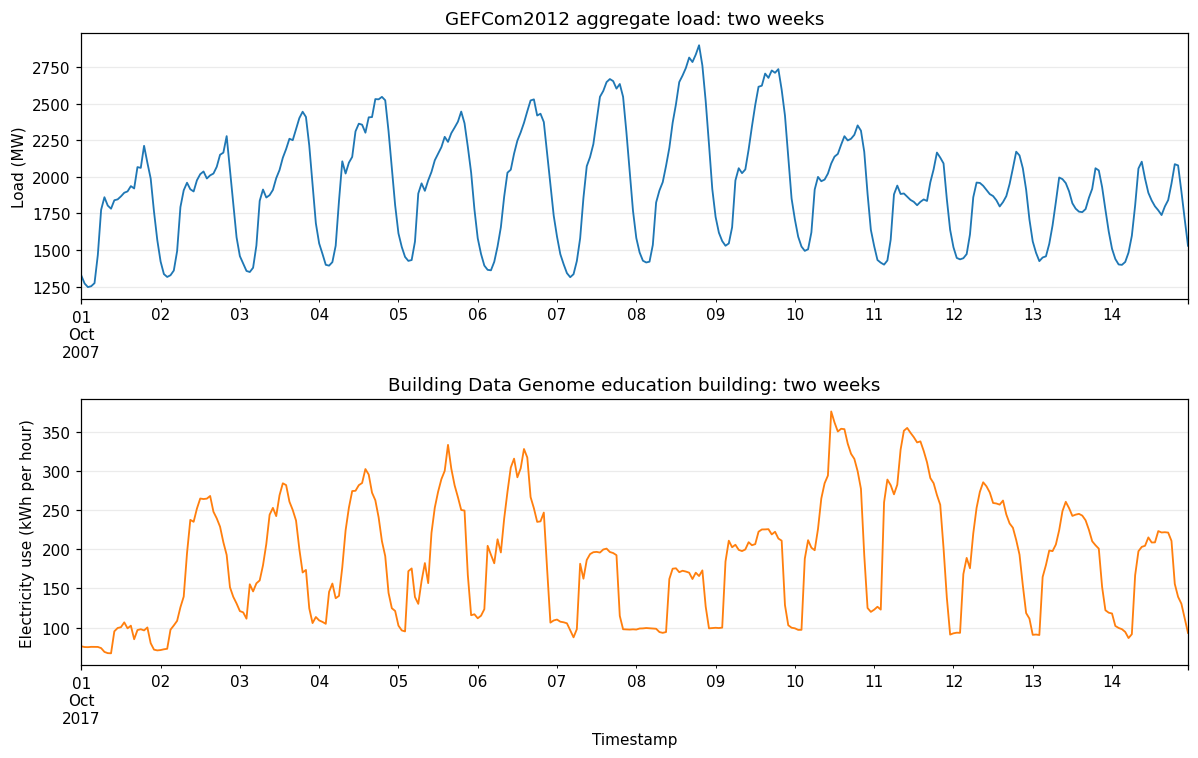

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7))

system_data.loc["2007-10-01":"2007-10-14", "load_mw"].plot(
    ax=axes[0], color="tab:blue", linewidth=1.2
)
axes[0].set(title="GEFCom2012 aggregate load: two weeks", ylabel="Load (MW)", xlabel="")

building_data.loc["2017-10-01":"2017-10-14", "electricity_kwh"].plot(
    ax=axes[1], color="tab:orange", linewidth=1.2
)
axes[1].set(
    title="Building Data Genome education building: two weeks",
    ylabel="Electricity use (kWh per hour)",
    xlabel="Timestamp",
)

plt.tight_layout()
plt.show()

### 1.2 Typical daily profiles

Calculate mean load by hour of day. For the building, separate weekdays and weekends.

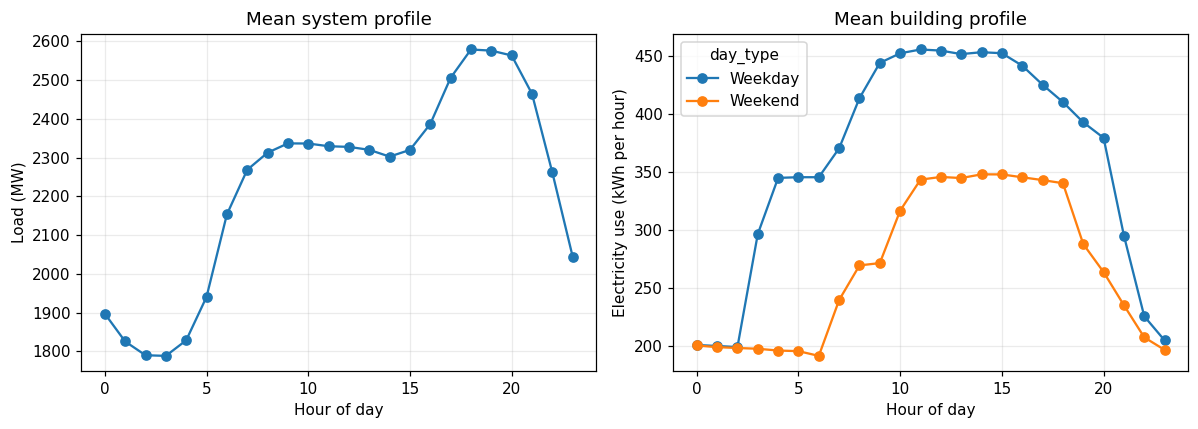

In [25]:
system_profile = system_data.groupby(system_data.index.hour)["load_mw"].mean()

building_for_profile = building_data.assign(
    day_type=np.where(building_data.index.dayofweek < 5, "Weekday", "Weekend")
)
building_profile = building_for_profile.groupby(
    [building_for_profile.index.hour, "day_type"]
)["electricity_kwh"].mean().unstack()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
system_profile.plot(ax=axes[0], marker="o", color="tab:blue")
axes[0].set(title="Mean system profile", xlabel="Hour of day", ylabel="Load (MW)")

building_profile.plot(ax=axes[1], marker="o")
axes[1].set(
    title="Mean building profile",
    xlabel="Hour of day",
    ylabel="Electricity use (kWh per hour)",
)
plt.tight_layout()
plt.show()

### 1.3 Building day–hour heatmap

Create one row per date and one column per hour. Look for weekday/weekend structure, closures and unusual days.

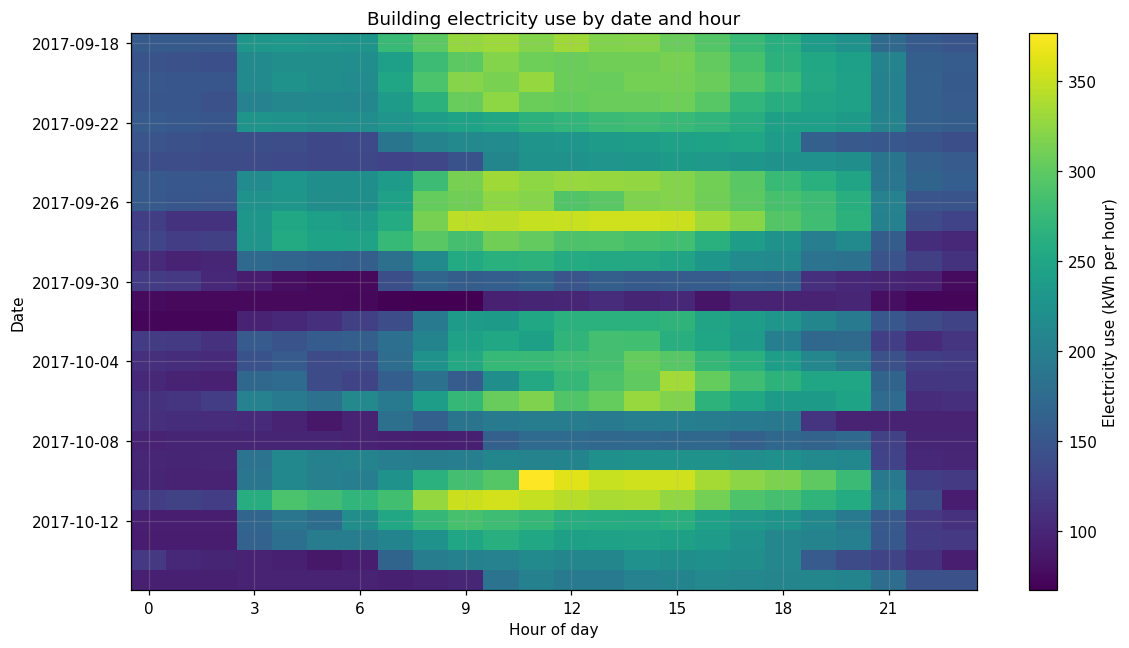

In [26]:
heatmap_source = building_data.loc["2017-09-18":"2017-10-15", ["electricity_kwh"]].copy()
heatmap_source["date"] = heatmap_source.index.date
heatmap_source["hour"] = heatmap_source.index.hour
building_heatmap = heatmap_source.pivot(index="date", columns="hour", values="electricity_kwh")

fig, ax = plt.subplots(figsize=(11, 6))
image = ax.imshow(building_heatmap, aspect="auto", cmap="viridis")
ax.set(title="Building electricity use by date and hour", xlabel="Hour of day", ylabel="Date")
ax.set_xticks(range(0, 24, 3))
ax.set_yticks(range(0, len(building_heatmap), 4))
ax.set_yticklabels([building_heatmap.index[i] for i in range(0, len(building_heatmap), 4)])
fig.colorbar(image, ax=ax, label="Electricity use (kWh per hour)")
plt.tight_layout()
plt.show()

### 1.4 Weather and variability

Plot electricity use against air temperature and calculate the coefficient of variation, defined as standard deviation divided by mean. This is only an illustration: the two datasets also differ in climate, use and measurement context, so scale alone cannot explain every difference.

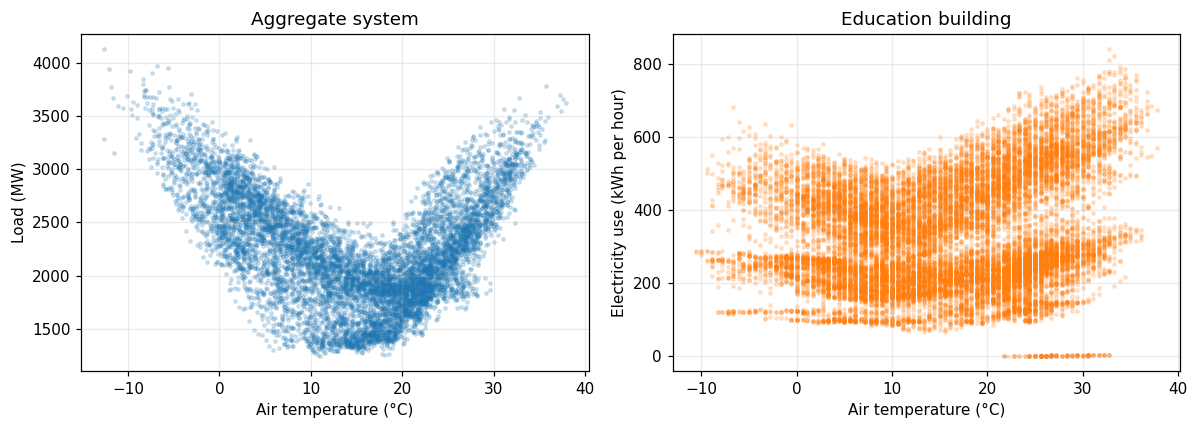

,coefficient_of_variation
GEFCom aggregate,0.225
BDG2 building,0.444


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(
    system_data["air_temperature_c"], system_data["load_mw"],
    s=5, alpha=0.18, color="tab:blue"
)
axes[0].set(xlabel="Air temperature (°C)", ylabel="Load (MW)", title="Aggregate system")

axes[1].scatter(
    building_data["air_temperature_c"], building_data["electricity_kwh"],
    s=5, alpha=0.18, color="tab:orange"
)
axes[1].set(
    xlabel="Air temperature (°C)",
    ylabel="Electricity use (kWh per hour)",
    title="Education building",
)
plt.tight_layout()
plt.show()

variability = pd.Series({
    "GEFCom aggregate": system_data["load_mw"].std() / system_data["load_mw"].mean(),
    "BDG2 building": building_data["electricity_kwh"].std() / building_data["electricity_kwh"].mean(),
}, name="coefficient_of_variation")
variability.to_frame().round(3)

**Discuss briefly**

1. Which series has the clearer daily cycle?
2. What differences do you see between building weekdays and weekends?
3. Which dates in the heatmap deserve further investigation?
4. Why should a low or zero building reading not automatically be treated as genuine low demand?

## 3. Task 2 — Define an origin-valid day-ahead forecast

For each day in the test period, we issue a forecast at the end of the preceding day for all 24 hours of the next day. The complete test table is later predicted in one vectorised calculation, but each row must still respect its own day-ahead information set.

```text
observed history                    forecast day
... D-2 ... | ... D-1 ... 23:00 || D 00:00 ........ D 23:00
                              origin   lead 1 ........ lead 24
```

At the origin we know:

- past load and weather values available before the origin;
- the target timestamps and their calendar information; and
- any genuine weather forecast issued before the origin.

We do **not** know realised target-day load. For the building dataset, we also do not know the observed target-day weather.

> Operational note: day-ahead electricity forecasts are commonly issued around 11:00–12:00 on day D−1. Using the end of D−1 here is a simplification that keeps every target day aligned to a 24-hour block.

### Temperature information in the supplied datasets

GEFCom2012 labels its training weather file `Temperature_history`. It contains historical weather forecasts aligned by valid timestamp with the load; `history` identifies the training dataset rather than realised weather. Building Data Genome 2 instead uses NOAA ISD-Lite observations recorded at the nearest hour of actual observation.

For simplicity, we deliberately use the same previous-day weather feature for both datasets:

$$
\widehat{T}_{D,h\mid D-1} = T_{D-1,h}.
$$

The feature is named `temperature_persistence_c`. For GEFCom, its right-hand side is the previous day's weather-forecast value; for Building Data Genome 2, it is the previous day's observed temperature. The supplied target-hour GEFCom forecast could be used directly, but we reserve that specification for Tutorial 4.2.

**Question:** Why would `load_lag_1` be invalid for most hours of a 24-hour fixed-origin forecast, even though it is a past value in an ordinary one-step-ahead dataset?

## 4. Task 3 — Construct forecasting features

The feature function is intentionally short. Every row represents a target timestamp. The load lags and previous-day temperature values are available before the corresponding day-ahead origin.

Complete the lagged features and the calendar variables. Store the preceding day's same-hour weather value as `temperature_persistence_c`. The pooled Ridge model uses cyclical calendar features. Both the decision tree and random forest use the same integer hour and day-of-week features, so their comparison does not confound model type with different inputs.

In [7]:
def make_features(data, target_column, temperature_column):
    features = pd.DataFrame(index=data.index)
    features["target"] = data[target_column]
    features["load_lag_24"] = data[target_column].shift(24)
    features["load_lag_168"] = data[target_column].shift(168)
    features["temperature_persistence_c"] = data[temperature_column].shift(24)

    hour = features.index.hour
    day_of_week = features.index.dayofweek
    features["hour"] = hour
    features["day_of_week"] = day_of_week
    features["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    features["hour_cos"] = np.cos(2 * np.pi * hour / 24)
    features["day_sin"] = np.sin(2 * np.pi * day_of_week / 7)
    features["day_cos"] = np.cos(2 * np.pi * day_of_week / 7)
    features["is_weekend"] = (day_of_week >= 5).astype(int)
    return features.dropna()

In [8]:
BASE_FEATURES = [
    "load_lag_24",
    "load_lag_168",
    "temperature_persistence_c",
    "is_weekend",
]

CYCLICAL_FEATURES = BASE_FEATURES + [
    "hour_sin",
    "hour_cos",
    "day_sin",
    "day_cos",
]

INTEGER_FEATURES = BASE_FEATURES + ["hour", "day_of_week"]

# Linear Ridge uses smooth cyclical encodings. Both tree models use the same
# compact integer calendar representation.
RIDGE_FEATURES = CYCLICAL_FEATURES
TREE_FEATURES = INTEGER_FEATURES

# The hour-specific Ridge model uses daily profiles of these lagged inputs.
# It does not need explicit hour or calendar encodings.
HOURLY_RIDGE_INPUTS = [
    "load_lag_24",
    "load_lag_168",
    "temperature_persistence_c",
]

system_features = make_features(system_data, "load_mw", "air_temperature_c")
system_features.head()

,target,load_lag_24,load_lag_168,temperature_persistence_c,hour,day_of_week,hour_sin,hour_cos,day_sin,day_cos,is_weekend
timestamp,,,,,,,,,,,
2007-01-08 00:00:00,1679.220,1580.772,1859.682,10.6566,0,0,0.000000,1.000000,0.0,1.0,0
2007-01-08 01:00:00,1546.498,1495.691,1761.282,10.3030,1,0,0.258819,0.965926,0.0,1.0,0
2007-01-08 02:00:00,1541.381,1489.298,1660.252,9.3939,2,0,0.500000,0.866025,0.0,1.0,0
2007-01-08 03:00:00,1559.906,1487.472,1617.558,8.5859,3,0,0.707107,0.707107,0.0,1.0,0
2007-01-08 04:00:00,1620.635,1510.853,1610.163,7.8283,4,0,0.866025,0.500000,0.0,1.0,0


### Chronological split for GEFCom2012

- training: 8 January to 30 June 2007;
- validation: July 2007;
- test: 1–28 August 2007.

The validation month lets us check the modelling choices before opening the test period. The final test forecasts use models refitted on training plus validation data.

In [9]:
TRAIN_START = pd.Timestamp("2007-01-08 00:00")
TRAIN_END = pd.Timestamp("2007-06-30 23:00")
VALIDATION_START = pd.Timestamp("2007-07-01 00:00")
VALIDATION_END = pd.Timestamp("2007-07-31 23:00")
TEST_START = pd.Timestamp("2007-08-01 00:00")
TEST_END = pd.Timestamp("2007-08-28 23:00")

train = system_features.loc[TRAIN_START:TRAIN_END]
validation = system_features.loc[VALIDATION_START:VALIDATION_END]
test = system_features.loc[TEST_START:TEST_END]

assert len(validation) == 31 * 24
assert len(test) == 28 * 24
assert not train.isna().any().any()
assert not validation.isna().any().any()
assert not test.isna().any().any()

pd.Series({"training rows": len(train), "validation rows": len(validation), "test rows": len(test)})

training rows      4176
validation rows     744
test rows           672
dtype: int64

## 5. Task 4 — Seasonal-naïve benchmarks and metrics

Create daily and weekly seasonal-naïve forecasts for the validation month. Because the corresponding lag columns contain only past observations, no fitted function is needed.

In [10]:
validation_forecasts = pd.DataFrame(index=validation.index)
validation_forecasts["Actual"] = validation["target"]
validation_forecasts["Daily seasonal naive"] = validation["load_lag_24"]
validation_forecasts["Weekly seasonal naive"] = validation["load_lag_168"]
validation_forecasts.head()

,Actual,Daily seasonal naive,Weekly seasonal naive
timestamp,,,
2007-07-01 00:00:00,1676.802,1854.713,1542.730
2007-07-01 01:00:00,1546.216,1725.731,1442.242
2007-07-01 02:00:00,1462.046,1648.889,1360.432
2007-07-01 03:00:00,1405.368,1601.522,1329.065
2007-07-01 04:00:00,1384.340,1584.329,1320.124


The scoring helper is supplied. MASE uses the mean absolute **weekly seasonal difference in the training series** as its scale:

$$
\mathrm{MASE}=\frac{\mathrm{mean}(|y_t-\hat y_t|)}
{\mathrm{mean}(|y_t-y_{t-168}|)\text{ in training})}.
$$

The denominator is a training-data benchmark. A weekly seasonal-naïve forecast evaluated over a different validation or test period is therefore not guaranteed to have MASE exactly equal to one.

In [11]:
def forecast_scores(actual, forecast, training_series, m=168):
    if isinstance(actual, pd.Series) and isinstance(forecast, pd.Series):
        if not actual.index.equals(forecast.index):
            raise ValueError("Actual and forecast indices must match.")
    actual = np.asarray(actual, dtype=float)
    forecast = np.asarray(forecast, dtype=float)
    if len(actual) != len(forecast):
        raise ValueError("Actual and forecast must have the same length.")

    errors = actual - forecast
    # Keep missing rows in place so that diff(m) still means exactly m hours.
    training_series = pd.Series(training_series, dtype=float)
    scale = training_series.diff(m).abs().dropna().mean()
    if not np.isfinite(scale) or scale == 0:
        raise ValueError("The MASE scaling denominator is invalid or zero.")

    return {
        "MAE": np.mean(np.abs(errors)),
        "RMSE": np.sqrt(np.mean(errors ** 2)),
        "MASE (m=168)": np.mean(np.abs(errors)) / scale,
    }

In [12]:
validation_scores = pd.DataFrame({
    model_name: forecast_scores(
        validation_forecasts["Actual"],
        validation_forecasts[model_name],
        train["target"],
    )
    for model_name in ["Daily seasonal naive", "Weekly seasonal naive"]
}).T
validation_scores.round(2)

,MAE,RMSE,MASE (m=168)
Daily seasonal naive,142.97,178.45,0.47
Weekly seasonal naive,298.24,369.28,0.98


## 6. Task 5 — Fit simple machine-learning models

We begin with three models:

- **pooled Ridge regression:** one linear model for all hours, using standardised cyclical predictors;
- **a decision tree:** a single nonlinear model using integer hour and day-of-week predictors; and
- **a random forest:** an average of many trees using exactly the same predictors as the single tree.

Holding the tree inputs constant makes their comparison easier to interpret. A preliminary validation comparison found that integer calendar variables worked slightly better for the random forest than cyclical or one-hot representations, so both tree methods use the integer representation here. The model settings are specified rather than tuned extensively.

In [13]:
ridge_model = make_pipeline(
    StandardScaler(),
    Ridge(alpha=10.0),
)

tree_model = DecisionTreeRegressor(
    max_depth=8,
    min_samples_leaf=20,
    random_state=42,
)

rf_model = RandomForestRegressor(
    n_estimators=150,
    min_samples_leaf=4,
    max_features=0.8,
    random_state=42,
    n_jobs=1,
)

ridge_model.fit(train[RIDGE_FEATURES], train["target"])
tree_model.fit(train[TREE_FEATURES], train["target"])
rf_model.fit(train[TREE_FEATURES], train["target"])

validation_forecasts["Pooled Ridge"] = ridge_model.predict(
    validation[RIDGE_FEATURES]
)
validation_forecasts["Tree"] = tree_model.predict(validation[TREE_FEATURES])
validation_forecasts["Random forest"] = rf_model.predict(
    validation[TREE_FEATURES]
)

### Task 5.5 — One Ridge model for each hour of the day

The pooled Ridge model assumes that one set of coefficients is suitable for every hour. A simple alternative is to reshape the data so that:

- each **row** represents one day;
- the 24 target **columns** represent hours 00:00 to 23:00; and
- the inputs contain the preceding-day load profile, preceding-week load profile and preceding-day weather profile.

We then fit 24 small Ridge models: target column 0 has its own model, target column 1 has another, and so on. Explicit hour-of-day and calendar-seasonality terms are omitted because each model always predicts the same hour, while the lagged profiles already carry recent daily and weekly information. This arrangement is also useful for problems such as day-ahead solar forecasting, where each daylight hour can have a different relationship with its predictors.

In [14]:
def reshape_complete_days(feature_data, predictor_columns):
    '''Return daily predictor and target matrices from complete hourly days.'''
    if len(feature_data) % 24 != 0:
        raise ValueError("The selected interval must contain complete 24-hour days.")
    if feature_data.index[0].hour != 0 or feature_data.index[-1].hour != 23:
        raise ValueError("The interval must start at 00:00 and end at 23:00.")

    expected_index = pd.date_range(
        feature_data.index[0], feature_data.index[-1], freq="h"
    )
    if not feature_data.index.equals(expected_index):
        raise ValueError("The interval must have a continuous hourly index.")

    predictor_blocks = [
        feature_data[column].to_numpy().reshape(-1, 24)
        for column in predictor_columns
    ]
    X_daily = np.hstack(predictor_blocks)
    y_daily = feature_data["target"].to_numpy().reshape(-1, 24)
    return X_daily, y_daily


def fit_hourly_ridge_models(X_daily, y_daily, alpha=10.0):

    models = []
    for hour in range(24):
        model = make_pipeline(StandardScaler(), Ridge(alpha=alpha))
        model.fit(X_daily, y_daily[:, hour])
        models.append(model)
    return models


def predict_hourly_ridge(models, X_daily):
    '''Predict all 24 hourly columns and return a daily matrix.'''
    return np.column_stack([model.predict(X_daily) for model in models])


X_train_daily, y_train_daily = reshape_complete_days(
    train, HOURLY_RIDGE_INPUTS
)
X_validation_daily, y_validation_daily = reshape_complete_days(
    validation, HOURLY_RIDGE_INPUTS
)

hourly_ridge_models = fit_hourly_ridge_models(
    X_train_daily, y_train_daily, alpha=10.0
)
hourly_ridge_validation = predict_hourly_ridge(
    hourly_ridge_models, X_validation_daily
)

# Flatten row by row to recover the original chronological hourly order.
validation_forecasts["Hourly Ridge"] = hourly_ridge_validation.reshape(-1)

In [15]:
validation_scores = pd.DataFrame({
    model_name: forecast_scores(
        validation_forecasts["Actual"],
        validation_forecasts[model_name],
        train["target"],
    )
    for model_name in validation_forecasts.columns.drop("Actual")
}).T.sort_values("RMSE")
validation_scores.round(2)

,MAE,RMSE,MASE (m=168)
Hourly Ridge,113.82,145.00,0.37
Pooled Ridge,136.06,165.72,0.45
Daily seasonal naive,142.97,178.45,0.47
Random forest,148.33,190.34,0.49
Tree,152.94,196.04,0.50
Weekly seasonal naive,298.24,369.28,0.98


## 7. Task 6 — Forecast the complete test set

Refit the models on the combined training and validation period, then predict the complete four-week test table directly. Scikit-learn can predict all test rows in one call, and the hour-specific Ridge models predict the complete daily matrix at once.

This vectorised calculation still represents repeated day-ahead forecasts. For each target day, `load_lag_24`, `load_lag_168` and `temperature_persistence_c` contain only information that would be available at that day's forecast origin. We are **not** claiming that all four weeks were forecast from one origin.

In [16]:
development = system_features.loc[TRAIN_START:VALIDATION_END]

ridge_model.fit(development[RIDGE_FEATURES], development["target"])
tree_model.fit(development[TREE_FEATURES], development["target"])
rf_model.fit(development[TREE_FEATURES], development["target"])

X_development_daily, y_development_daily = reshape_complete_days(
    development, HOURLY_RIDGE_INPUTS
)
X_test_daily, y_test_daily = reshape_complete_days(test, HOURLY_RIDGE_INPUTS)

hourly_ridge_models = fit_hourly_ridge_models(
    X_development_daily, y_development_daily, alpha=10.0
)
hourly_ridge_test = predict_hourly_ridge(hourly_ridge_models, X_test_daily)

system_forecasts = pd.DataFrame(index=test.index)
system_forecasts["Actual"] = test["target"]
system_forecasts["Daily seasonal naive"] = test["load_lag_24"]
system_forecasts["Weekly seasonal naive"] = test["load_lag_168"]
system_forecasts["Pooled Ridge"] = ridge_model.predict(test[RIDGE_FEATURES])
system_forecasts["Hourly Ridge"] = hourly_ridge_test.reshape(-1)
system_forecasts["Tree"] = tree_model.predict(test[TREE_FEATURES])
system_forecasts["Random forest"] = rf_model.predict(test[TREE_FEATURES])

assert len(system_forecasts) == 28 * 24
system_forecasts.head()

,Actual,Daily seasonal naive,Weekly seasonal naive,Pooled Ridge,Hourly Ridge,Tree,Random forest
timestamp,,,,,,,
2007-08-01 00:00:00,1867.021,1872.727,1662.969,1838.102558,1933.197609,1804.961969,1858.640506
2007-08-01 01:00:00,1730.259,1739.555,1573.257,1716.924582,1799.003644,1712.203071,1721.325783
2007-08-01 02:00:00,1641.475,1663.403,1506.805,1644.240376,1699.696657,1787.772667,1707.991294
2007-08-01 03:00:00,1590.345,1627.936,1481.278,1611.189821,1646.747174,1640.206600,1683.726731
2007-08-01 04:00:00,1593.823,1633.389,1515.812,1621.946500,1653.720035,1640.206600,1682.965221


In [17]:
system_scores = pd.DataFrame({
    model_name: forecast_scores(
        system_forecasts["Actual"],
        system_forecasts[model_name],
        development["target"],
    )
    for model_name in system_forecasts.columns.drop("Actual")
}).T.sort_values("RMSE")
system_scores.round(2)

,MAE,RMSE,MASE (m=168)
Hourly Ridge,145.28,203.09,0.48
Random forest,164.15,209.28,0.54
Pooled Ridge,162.43,210.97,0.54
Daily seasonal naive,174.46,235.16,0.58
Tree,184.04,240.96,0.61
Weekly seasonal naive,295.75,359.50,0.98


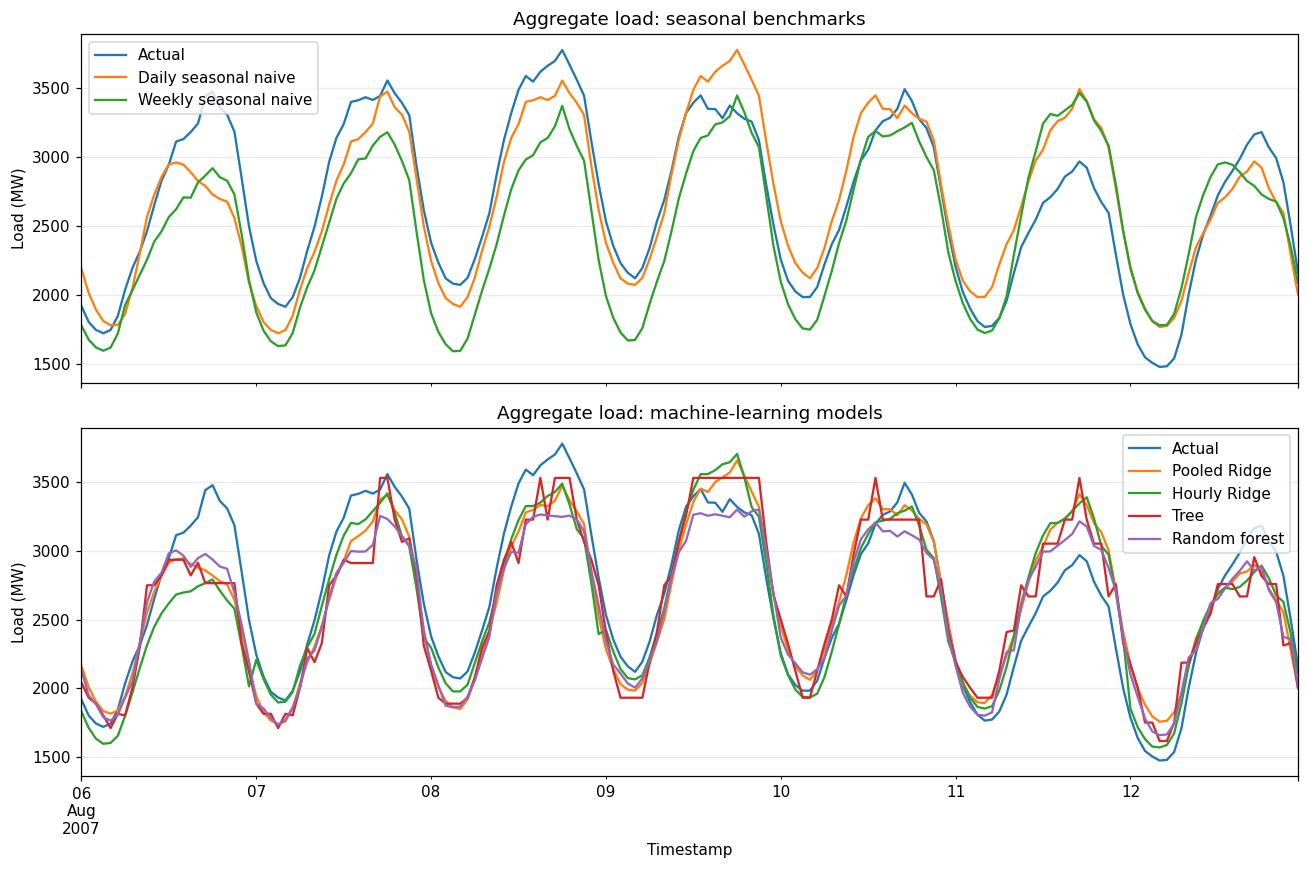

In [18]:
plot_week = system_forecasts.loc["2007-08-06":"2007-08-12"]

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
plot_week[["Actual", "Daily seasonal naive", "Weekly seasonal naive"]].plot(ax=axes[0])
axes[0].set(title="Aggregate load: seasonal benchmarks", ylabel="Load (MW)", xlabel="")

plot_week[
    ["Actual", "Pooled Ridge", "Hourly Ridge", "Tree", "Random forest"]
].plot(ax=axes[1])
axes[1].set(title="Aggregate load: machine-learning models", ylabel="Load (MW)", xlabel="Timestamp")

plt.tight_layout()
plt.show()

## 8. Task 7 — Local and transferred models for an individual building

The system model was trained on aggregate load measured in MW, while the building meter records hourly energy in kWh. A direct application would therefore mix incompatible scales. Before transfer, divide the target and both load-lag features by the mean load of the corresponding development period.

We compare:

- **transferred Ridge:** coefficients are fitted only on normalized GEFCom data and then applied to normalized building predictors;
- **local Ridge:** the same model form is fitted on the available building-development data; and
- **local tree:** a nonlinear local comparison using the same integer feature set as the earlier tree models.

The transferred model uses the building-development mean to convert normalized forecasts back to kWh. This is a limited **scale adaptation**, not strict zero-shot transfer, but its regression coefficients never see building targets during fitting. The local model uses all available building data before the test period.

The building split is:

- local training: 8 January 2016 to 31 August 2017;
- validation and additional development data: September 2017;
- test: 1–28 October 2017.

Rows affected by missing target, lag or weather-proxy values are excluded by `make_features`. The October test period is complete after feature construction.

An unconstrained regression model can produce negative values. Negative electricity use is not physically meaningful, so after counting them we apply

$$
\hat{y}^{+}_t = \max(0, \hat{y}_t).
$$

The count makes this physical correction explicit.

In [19]:
building_features = make_features(
    building_data,
    target_column="electricity_kwh",
    temperature_column="air_temperature_c",
)

BUILDING_TRAIN_START = pd.Timestamp("2016-01-08 00:00")
BUILDING_TRAIN_END = pd.Timestamp("2017-08-31 23:00")
BUILDING_VALIDATION_START = pd.Timestamp("2017-09-01 00:00")
BUILDING_VALIDATION_END = pd.Timestamp("2017-09-30 23:00")
BUILDING_TEST_START = pd.Timestamp("2017-10-01 00:00")
BUILDING_TEST_END = pd.Timestamp("2017-10-28 23:00")

building_development = building_features.loc[
    BUILDING_TRAIN_START:BUILDING_VALIDATION_END
]
building_test = building_features.loc[BUILDING_TEST_START:BUILDING_TEST_END]
building_mase_training_series = building_data.loc[
    BUILDING_TRAIN_START:BUILDING_VALIDATION_END, "electricity_kwh"
]

assert len(building_test) == 28 * 24
assert not building_test.isna().any().any()

In [20]:
LOAD_SCALE_COLUMNS = ["target", "load_lag_24", "load_lag_168"]


def normalise_load_scale(feature_data, load_scale):
    if not np.isfinite(load_scale) or load_scale <= 0:
        raise ValueError("load_scale must be finite and positive.")
    normalised = feature_data.copy()
    normalised[LOAD_SCALE_COLUMNS] = (
        normalised[LOAD_SCALE_COLUMNS] / load_scale
    )
    return normalised


# The transferred coefficients are learnt from GEFCom only.
system_transfer_scale = development["target"].mean()
building_load_scale = building_development["target"].mean()

system_transfer_development = normalise_load_scale(
    development, system_transfer_scale
)
building_development_normalised = normalise_load_scale(
    building_development, building_load_scale
)
building_test_normalised = normalise_load_scale(
    building_test, building_load_scale
)


transferred_ridge = make_pipeline(StandardScaler(), Ridge(alpha=10.0))
local_ridge = make_pipeline(StandardScaler(), Ridge(alpha=10.0))
local_tree = DecisionTreeRegressor(
    max_depth=8,
    min_samples_leaf=20,
    random_state=42,
)

transferred_ridge.fit(
    system_transfer_development[RIDGE_FEATURES],
    system_transfer_development["target"],
)
local_ridge.fit(
    building_development_normalised[RIDGE_FEATURES],
    building_development_normalised["target"],
)
local_tree.fit(
    building_development_normalised[TREE_FEATURES],
    building_development_normalised["target"],
)

building_forecasts = pd.DataFrame(index=building_test.index)
building_forecasts["Actual"] = building_test["target"]
building_forecasts["Daily seasonal naive"] = building_test["load_lag_24"]
building_forecasts["Weekly seasonal naive"] = building_test["load_lag_168"]
building_forecasts["Transferred Ridge"] = building_load_scale * transferred_ridge.predict(
    building_test_normalised[RIDGE_FEATURES]
)
building_forecasts["Local Ridge"] = building_load_scale * local_ridge.predict(
    building_test_normalised[RIDGE_FEATURES]
)
building_forecasts["Local tree"] = building_load_scale * local_tree.predict(
    building_test_normalised[TREE_FEATURES]
)

building_model_columns = building_forecasts.columns.drop("Actual")
negative_forecast_counts = (
    building_forecasts[building_model_columns] < 0
).sum()
print("Negative forecasts before projection:")
display(negative_forecast_counts.to_frame("Count"))

building_forecasts.loc[:, building_model_columns] = building_forecasts[
    building_model_columns
].clip(lower=0)
assert (building_forecasts[building_model_columns] >= 0).all().all()

building_scores = pd.DataFrame({
    model_name: forecast_scores(
        building_forecasts["Actual"],
        building_forecasts[model_name],
        building_mase_training_series,
    )
    for model_name in building_model_columns
}).T.sort_values("RMSE")
building_scores.round(2)

Negative forecasts before projection:


,Count
Daily seasonal naive,0
Weekly seasonal naive,0
Transferred Ridge,0
Local Ridge,0
Local tree,0


,MAE,RMSE,MASE (m=168)
Local Ridge,33.68,41.92,0.64
Transferred Ridge,34.39,44.45,0.65
Local tree,35.61,45.10,0.67
Weekly seasonal naive,42.11,54.09,0.80
Daily seasonal naive,38.90,54.49,0.74


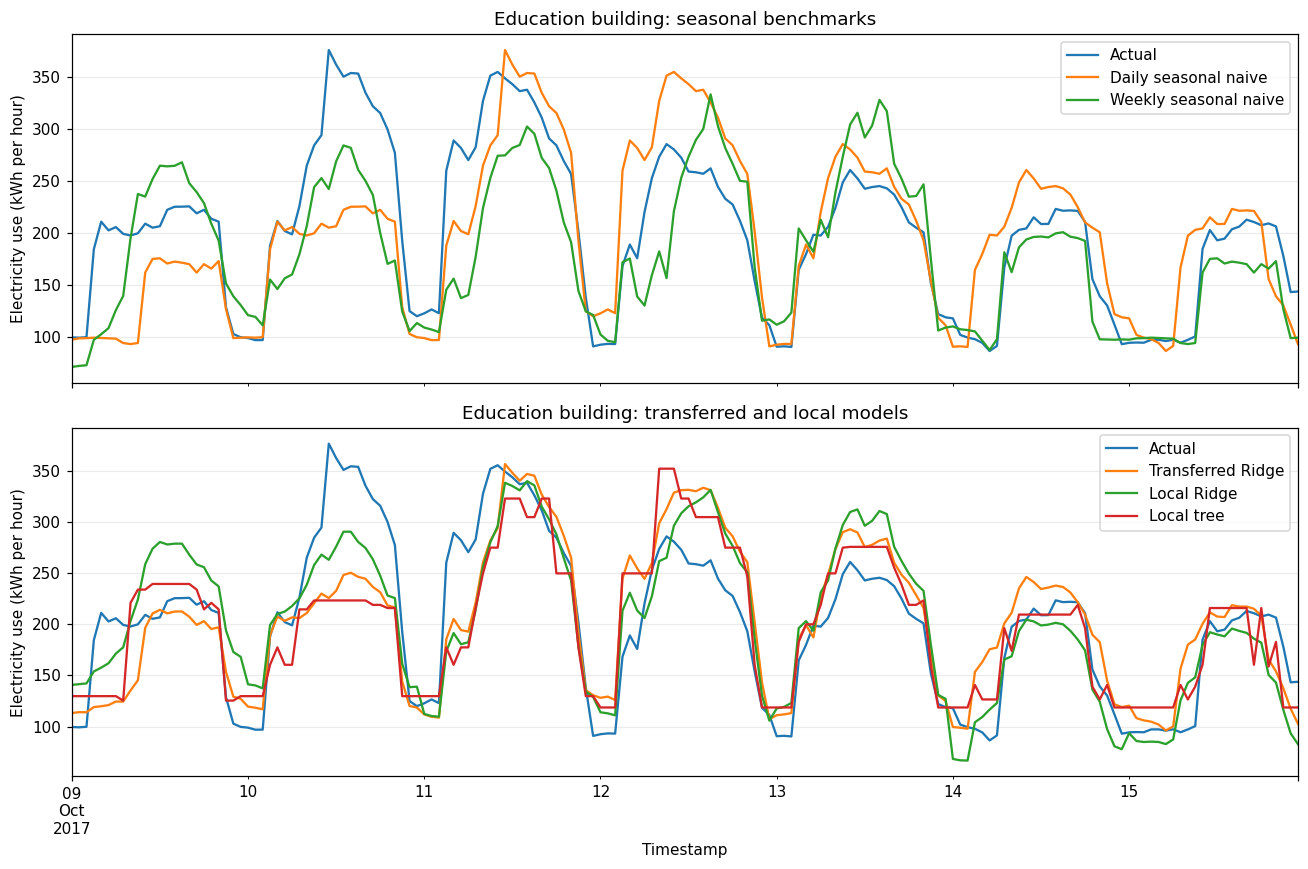

In [21]:
building_plot_week = building_forecasts.loc["2017-10-09":"2017-10-15"]

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
building_plot_week[["Actual", "Daily seasonal naive", "Weekly seasonal naive"]].plot(ax=axes[0])
axes[0].set(
    title="Education building: seasonal benchmarks",
    ylabel="Electricity use (kWh per hour)",
    xlabel="",
)

building_plot_week[
    ["Actual", "Transferred Ridge", "Local Ridge", "Local tree"]
].plot(ax=axes[1])
axes[1].set(
    title="Education building: transferred and local models",
    ylabel="Electricity use (kWh per hour)",
    xlabel="Timestamp",
)
plt.tight_layout()
plt.show()

## 9. Interpretation questions

1. **Which method performs best for aggregate load under MAE, RMSE and MASE?**  
   Use the test table rather than the validation table. In this run, the hour-specific Ridge benchmark has the lowest MAE, RMSE and MASE. Its test RMSE is 203.09 MW, compared with 209.28 MW for the random forest and 210.97 MW for pooled Ridge.

2. **How does the hour-specific Ridge benchmark compare with the pooled Ridge model?**  
   The hour-specific approach performs better here: its test RMSE is 203.09 MW rather than 210.97 MW. Separate models can learn a different relationship for every hour, whereas the pooled model shares one set of coefficients and represents time of day through cyclical inputs.

3. **Why are explicit hour-of-day variables unnecessary in the hour-specific Ridge models?**  
   Each target column always represents one fixed hour, so its model never has to distinguish 08:00 from 18:00. The column itself defines the forecast hour, and the lagged daily profiles provide the recent temporal context.

4. **Why can the complete test table be predicted in one call without implying a four-week-ahead forecast from one origin?**  
   Every test row contains lagged predictors appropriate to its own day-ahead origin. Vectorisation changes how the calculation is written, not the information assumed to be available for each forecast day.

5. **How does the transferred Ridge model compare with the local Ridge model and the building benchmarks? Why might their performance differ?**  
   Local Ridge performs best with an RMSE of 41.92 kWh, while transferred Ridge reaches 44.45 kWh and still improves on both seasonal benchmarks. The transferred coefficients come from aggregate system behaviour, whereas the local model learns the education building's schedule and weather response. Normalisation reconciles scale, but it cannot remove differences in occupancy, control and aggregation.

6. **Why is the weekly seasonal-naïve model a compulsory benchmark here?**  
   Hourly electricity demand has a strong weekly schedule. A more complicated model is useful only if it improves on simply reusing the same hour from the preceding week.

7. **What exactly is the reference forecast in the MASE denominator? Why need the test-set weekly forecast not have MASE equal to one?**  
   The denominator is the mean absolute 168-hour seasonal difference calculated from the development data. The numerator is measured over the test period, so the test-period weekly forecast faces different observations and is not constrained to equal the training scale.

8. **Why might aggregation make daily and weekly behaviour easier to forecast?**  
   Independent building-level fluctuations partly cancel when many customers are combined. The aggregate retains shared calendar and weather patterns while reducing the relative effect of one building's unusual operation.

9. **Why do we check for negative building forecasts, and what does projection to zero do?**  
   An unconstrained regression can extrapolate below zero even though electricity use cannot be negative. Projection replaces negative forecasts with zero while leaving non-negative values unchanged; reporting the count makes the correction visible.

10. **Which feature is only a weather-forecast proxy? How would you improve it operationally?**  
    `temperature_persistence_c` uses the previous day's same-hour weather value: a historical weather forecast for GEFCom and an observation for Building Data Genome 2. For GEFCom, the supplied target-hour forecast can be used directly; for the building, an operational study would need an archived day-ahead weather forecast.

11. **Identify one apparently sensible predictor that would leak future information in this day-ahead setting.**  
    Observed target-day building temperature would leak information. So would short load lags such as `load_lag_1` for later target hours, because those loads have not yet been observed when the full day-ahead forecast is issued. The target-hour GEFCom weather forecast is different: it is origin-valid, although Tutorial 4.1 deliberately uses the previous-day value for consistency between datasets.

## References

- Hong, T., Pinson, P. and Fan, S. (2014) ‘Global Energy Forecasting Competition 2012’, *International Journal of Forecasting*, 30(2), pp. 357–363. https://doi.org/10.1016/j.ijforecast.2013.07.001
- Miller, C. et al. (2020) ‘The Building Data Genome Project 2, energy meter data from the ASHRAE Great Energy Predictor III competition’, *Scientific Data*, 7, 368. https://doi.org/10.1038/s41597-020-00712-x